# Task 4 — Independent holdout search evaluation

This notebook is a replay of frozen evidence. It trains nothing, refits nothing,
makes no new predictions, and does not open a label source. The verified artifact
ledger is checked before any scored table is read.

## Plain-language output glossary

| Term | Plain meaning |
|---|---|
| Top-K | The first K products returned by a search. |
| gallery | The fixed set of products that a query is allowed to retrieve. |
| query | The image used to ask the search system for similar products. |
| relevance grade | A saved score saying how well one returned product matches the query metadata. |
| nDCG@10 | A zero-to-one score that rewards relevant products more when they appear near the top ten. |
| linear gain | A relevance grade of two counts exactly twice as much as a grade of one. |
| broad Precision@K | The share of the first K results that match the query's article type. |
| strict Precision@K | The share of the first K results that match both article type and base colour. |
| Recall@10 | The share of all eligible same-family products found in the first ten. |
| Hit Rate@10 | The share of scorable queries with at least one same-family result in the first ten. |
| tie rate | The share of adjacent returned distances that are equal at the reported cutoff. |
| coverage | The share of queries for which the metric has a valid answer. |
| family-blocked bootstrap | A repeat sample that keeps each product family together instead of sampling its images separately. |
| 95% percentile interval | The range from the 2.5th to the 97.5th percentile of the repeated samples. |
| cosine distance | One minus cosine similarity; smaller values mean closer embedding directions. |
| selective retrieval | Returning results only for queries whose nearest distance passes a cutoff. |
| source-robustness ratio | V1-query nDCG divided by teacher-query nDCG against the same teacher gallery. |
| delta | A difference from a named reference; its sign depends on the order printed in the label. |


## 1. Replay contract and verified gateway

The first action verifies the completed artifact ledger. Every later table is read only after this check succeeds.


In [1]:
import hashlib
import io
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image as DisplayImage
from IPython.display import Markdown, display

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").is_file():
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from fashion.task4_evaluation import load_verified_holdout_evaluation
from fashion.train.ranking_metrics import (
    paired_family_ranking_bootstrap,
    summarise_ranking_bootstrap,
)

EVALUATION_MODE = "artifact_replay"
EVIDENCE = ROOT / "results/evidence/task4/final_evaluation"
FIGURES = ROOT / "results/figures/task4/final_evaluation"
EVALUATION_MANIFEST_FILE = EVIDENCE / "evaluation_manifest.json"
HOLDOUT_ROWS_EXPECTED = 5778
DEVELOPMENT_GALLERY_ROWS_EXPECTED = 32773


def read_json(path: Path):
    with path.open("r", encoding="utf-8") as handle:
        return json.load(handle)


def show_table(table, note: str) -> None:
    display(table)
    display(Markdown(f"> **How to read this table.** {note}"))


def show_figure(path: Path, note: str, *, width: int | None = None) -> None:
    display(DisplayImage(filename=str(path), width=width))
    display(Markdown(f"> **How to read this figure.** {note}"))


evaluation_manifest = load_verified_holdout_evaluation()
prediction_receipt = read_json(EVIDENCE / "prediction_receipt.json")
assert evaluation_manifest["status"] == "complete"
assert evaluation_manifest["coverage"]["holdout_rows"] == HOLDOUT_ROWS_EXPECTED
print(
    {
        "mode": EVALUATION_MODE,
        "status": evaluation_manifest["status"],
        "holdout_rows": evaluation_manifest["coverage"]["holdout_rows"],
        "quarantine_rows_excluded": prediction_receipt["coverage"][
            "quarantine_rows_excluded"
        ],
    }
)


{'mode': 'artifact_replay', 'status': 'complete', 'holdout_rows': 5778, 'quarantine_rows_excluded': 61}


**Interpretation.**

- **Result:** The fail-closed gateway accepted one complete evaluation covering 5,778 holdout queries, with 61 quarantine rows excluded.
- **Meaning:** All scored files and all six figures matched their recorded SHA-256 and byte counts before replay began.
- **Decision:** Use these frozen artifacts only; do not train, refit, rank, predict, or rescore here.
- **Limitation:** Verification proves artifact identity and process flags, not that metadata relevance is the same as human visual judgement.
- **Trace:** `load_verified_holdout_evaluation()` verifies `evaluation_manifest.json`, `prediction_receipt.json`, the permanent attempt record, and the unlock receipt.


## 2. Frozen R5 model and gallery provenance

The submitted method is tied to one run, one checkpoint, one scratch-built package, and one all-development gallery.


In [2]:
model_manifest = read_json(ROOT / "models/task4_r5/manifest.json")
gallery_manifest = read_json(ROOT / "models/task4_holdout_gallery/manifest.json")
deployment_summary = pd.read_csv(EVIDENCE / "deployment_summary.csv")

provenance = pd.DataFrame(
    [
        {
            "method": model_manifest["method"],
            "run_id": model_manifest["source_checkpoint"]["run_id"],
            "checkpoint_sha256": model_manifest["source_checkpoint"]["sha256"],
            "selected_epoch": model_manifest["source_checkpoint"]["epoch"],
            "trained_from_scratch": model_manifest["pretrained"] is False,
            "parameter_count": int(deployment_summary.loc[0, "parameter_count"]),
            "embedding_dimension": model_manifest["embedding_dim"],
            "gallery_rows": gallery_manifest["rows"],
            "gallery_identity_sha256": gallery_manifest[
                "artifact_identity_sha256"
            ],
        }
    ]
)
assert provenance.loc[0, "selected_epoch"] == 80
assert provenance.loc[0, "parameter_count"] == 14_276_931
assert provenance.loc[0, "embedding_dimension"] == 128
assert provenance.loc[0, "gallery_rows"] == DEVELOPMENT_GALLERY_ROWS_EXPECTED
show_table(
    provenance.T.rename(columns={0: "Frozen value"}),
    "Read down the values as one identity chain. A changed run, hash, epoch, scratch flag, dimension, or gallery identity would describe a different system.",
)


,Frozen value
method,R5
run_id,task4-candidate-r5-task9-preexec
checkpoint_sha256,521e96f3df9e28853309bd607030523f59ef8425326da5...
selected_epoch,80
trained_from_scratch,True
parameter_count,14276931
embedding_dimension,128
gallery_rows,32773
gallery_identity_sha256,3612d94dd76ccf7ff55077c6381dc359e09ea6dd0cd586...


> **How to read this table.** Read down the values as one identity chain. A changed run, hash, epoch, scratch flag, dimension, or gallery identity would describe a different system.

**Interpretation.**

- **Result:** R5 is the epoch-80 scratch autoencoder with 14,276,931 parameters, a 128-value embedding, and the 32,773-product teacher gallery.
- **Meaning:** The reported holdout score belongs to this exact package and gallery, not merely to the name “R5.”
- **Decision:** Keep R5 as the submitted scratch model and keep the gallery fixed.
- **Limitation:** The gallery is development-only and teacher-style; it is not a live catalogue with changing stock.
- **Trace:** `models/task4_r5/manifest.json`, `models/task4_holdout_gallery/manifest.json`, and `deployment_summary.csv`.


## 3. Development comparison ladder

The pre-holdout record explains why R5 was selected. It is context, not a new selection step.


In [3]:
development_freeze = read_json(
    ROOT / "results/evidence/task4/final/task4-final-comparison.json"
)
method_order = ["R1", "R2", "R3", "R4", "R5", "B1"]
ladder = pd.DataFrame(
    [
        {
            "method": item["method"],
            "run_id": item["run_id"],
            "one_factor_change": item["factor_change"],
            "pretrained": item["pretrained"],
            "development_mean_nDCG@10": item["selected_metrics"][
                "development_winner_score"
            ],
            "cross_source_nDCG@10": item["selected_metrics"]["cross_source_score"],
            "development_source_ratio": item["selected_metrics"][
                "source_robustness_ratio"
            ],
            "parameters": item["cost"]["parameters"],
        }
        for item in development_freeze["methods"]
    ]
)
ladder["method"] = pd.Categorical(
    ladder["method"], categories=method_order, ordered=True
)
ladder = ladder.sort_values("method").reset_index(drop=True)
assert ladder["method"].astype(str).tolist() == method_order
show_table(
    ladder.round(4),
    "Read R1 through R5 as the scratch comparison ladder. B1 is shown last because its ImageNet weights make it benchmark evidence only.",
)


,method,run_id,one_factor_change,pretrained,development_mean_nDCG@10,cross_source_nDCG@10,development_source_ratio,parameters
0,R1,task4-candidate-r1-task9-retry2,Scratch ResNet-18 plus VICReg; base learned re...,False,0.2352,0.2267,0.9641,11769536
1,R2,task4-candidate-r2-task9-retry2,R1 with a larger scratch ResNet-34 encoder.,False,0.1987,0.1973,0.9928,21877696
2,R3,task4-candidate-r3-task9-preexec,R1 plus geometry and wide/tall canvas augmenta...,False,0.3102,0.3099,0.9992,11769536
3,R4,task4-candidate-r4-task9-preexec,R3 plus batch-hard product-family triplet loss.,False,0.3001,0.2997,0.9986,11769536
4,R5,task4-candidate-r5-task9-preexec,Independent scratch convolutional autoencoder ...,False,0.5029,0.5028,0.9998,14276931
5,B1,task4-benchmark-b1-task9-preexec,R1 recipe with ImageNet pretrained weights; co...,True,0.3133,0.3121,0.9959,11769536


> **How to read this table.** Read R1 through R5 as the scratch comparison ladder. B1 is shown last because its ImageNet weights make it benchmark evidence only.

**Interpretation.**

- **Result:** R5 had the strongest frozen development score, while B1 supplied an ineligible pretrained comparison rather than the final model.
- **Meaning:** The ladder tests architecture, geometry, triplet loss, and the independent autoencoder rather than reporting one isolated run.
- **Decision:** Preserve the predeclared R5 choice; P-style pretrained rows and B1 remain benchmark evidence only.
- **Limitation:** Development scores use four source pairings and fold-1 galleries, so they are not the same estimand as the holdout teacher-to-teacher score.
- **Trace:** `results/evidence/task4/final/task4-final-comparison.json`.


## 4. Blind prediction receipt and row audit

This section checks what existed before label access: rankings, query records, gallery records, and the prediction-time safety flags.


In [4]:
blind_artifacts = pd.DataFrame(
    [
        {
            "artifact": name,
            "path": record["path"],
            "rows": record.get("rows"),
            "bytes": record["bytes"],
            "sha256": record["sha256"],
        }
        for name, record in prediction_receipt["artifacts"].items()
    ]
).sort_values("artifact")
assert prediction_receipt["labels_opened"] is False
assert prediction_receipt["model_changed"] is False
assert prediction_receipt["retuning_allowed"] is False
assert prediction_receipt["coverage"]["development_gallery_rows"] == 32773
assert prediction_receipt["coverage"]["holdout_rows"] == 5778

query_record = prediction_receipt["artifacts"]["holdout_query_manifest"]
query_path = ROOT / query_record["path"]
query_bytes = query_path.read_bytes()
assert hashlib.sha256(query_bytes).hexdigest() == query_record["sha256"]
assert len(query_bytes) == query_record["bytes"]
query_manifest = pd.read_csv(io.BytesIO(query_bytes))
assert len(query_manifest) == query_record["rows"] == 11_556
assert query_manifest["articleType_redacted"].isna().all()

show_table(
    blind_artifacts,
    "Rows show blind coverage. SHA-256 and byte counts identify the exact frozen bytes; they do not measure quality.",
)


,artifact,path,rows,bytes,sha256
0,gallery_manifest,results/evidence/task4/final_evaluation/galler...,32773.0,3887890,6b4be696b1d47c4aca6930c4bee789c94d9b8895483f42...
1,holdout_family_rankings,results/evidence/task4/final_evaluation/holdou...,520020.0,30834037,22a48d83045ca22aa985deb5172a2cfa9a7bd0e538cad7...
2,holdout_primary_rankings,results/evidence/task4/final_evaluation/holdou...,3813480.0,292330199,ed8e5864417b25450627b426ce3017aa6f1b947db147ca...
3,holdout_query_manifest,results/evidence/task4/final_evaluation/holdou...,11556.0,2033119,2c53768723802c0110d3aed850e7de8e3cde19356fc45a...
4,runtime,results/evidence/task4/final_evaluation/blind_...,NaN,4345,520036838a83520994908ffe62fb1634e1b01858b3a376...


> **How to read this table.** Rows show blind coverage. SHA-256 and byte counts identify the exact frozen bytes; they do not measure quality.

**Interpretation.**

- **Result:** Blind prediction covered 32,773 gallery products and 5,778 holdout products in both teacher and V1 directions; protected article type remained blank in the query ledger.
- **Meaning:** Rankings were frozen before the one-time label access and cannot be regenerated now.
- **Decision:** Treat the published ranking bytes as permanent inputs to this replay.
- **Limitation:** At source commit `bf64d2b`, the real run used six non-image inputs before it hashed them. A clean commit and matching final hashes reduce concern, but cannot prove that no file changed during the run. Images and rankings were byte-bound. The scores stand and the one-shot run cannot be repeated. Decision 0028 records this limit; future runs snapshot those six inputs before use.
- **Trace:** `prediction_receipt.json`, `docs/decisions/0028-task4-blind-input-snapshot-proof-limit.md`, and the hashed gallery, query, primary-ranking, family-ranking, and runtime records.


## 5. One-time opening and no-change audit

The holdout is permanently open. These records show when access began and that the model, metric, conditions, and winner did not change afterward.


In [5]:
unlock_attempt = read_json(EVIDENCE / "unlock_attempt.json")
unlock_receipt = read_json(EVIDENCE / "unlock_receipt.json")

no_change = pd.DataFrame(
    [
        {"check": "attempt state", "recorded_value": unlock_attempt["state"]},
        {"check": "holdout opened", "recorded_value": unlock_receipt["holdout_opened"]},
        {"check": "model retrained", "recorded_value": unlock_receipt["model_retrained"]},
        {"check": "winner changed", "recorded_value": unlock_receipt["winner_changed"]},
        {"check": "metric changed", "recorded_value": unlock_receipt["metric_changed"]},
        {"check": "conditions changed", "recorded_value": unlock_receipt["conditions_changed"]},
        {"check": "retuning allowed", "recorded_value": unlock_receipt["retuning_allowed"]},
        {
            "check": "approval reference",
            "recorded_value": unlock_receipt["scoring_approval_ref"],
        },
    ]
)
assert unlock_attempt["state"] == "label_access_started"
assert unlock_receipt["holdout_opened"] is True
assert all(
    unlock_receipt[name] is False
    for name in (
        "model_retrained",
        "winner_changed",
        "metric_changed",
        "conditions_changed",
        "retuning_allowed",
    )
)
show_table(
    no_change,
    "The expected pattern is one true opening flag and false values for every post-opening change or retuning flag.",
)


,check,recorded_value
0,attempt state,label_access_started
1,holdout opened,True
2,model retrained,False
3,winner changed,False
4,metric changed,False
5,conditions changed,False
6,retuning allowed,False
7,approval reference,refs/tags/task4-holdout-scoring-approved-v1


> **How to read this table.** The expected pattern is one true opening flag and false values for every post-opening change or retuning flag.

**Interpretation.**

- **Result:** The permanent attempt record precedes the receipt, and all five no-change controls remain false.
- **Meaning:** The score is a one-shot judgement of the frozen system, not feedback for another model choice.
- **Decision:** Never rerun scoring or use this holdout for tuning.
- **Limitation:** One-time evaluation gives honest process evidence but no independent second holdout for confirmation.
- **Trace:** `unlock_attempt.json`, `unlock_receipt.json`, and the unchanged approval reference recorded by the verified manifest.


## 6. Holdout scorecard and development context

The primary headline is teacher-query linear nDCG@10. Supporting columns show class balance, broad and strict relevance, ties, and family retrieval.


,method,direction,benchmark_only,ndcg_at_10_query_mean,ndcg_at_10_article_type_macro,precision_any_at_10,precision_strict_at_10,recall_at_10,hit_rate_at_10,tie_rate_at_10,development_reference_ndcg_at_10,development_reference_comparable,holdout_minus_development_ndcg_at_10
0,b1_pretrained_resnet18,teacher,True,0.3195,0.1381,0.4529,0.1616,0.1175,0.2908,0.0506,NaN,NaN,NaN
1,b1_pretrained_resnet18,v1,True,0.3195,0.1350,0.4528,0.1610,0.1191,0.2921,0.0506,NaN,NaN,NaN
2,hog_hsv_edge_fusion,teacher,False,0.5151,0.4233,0.7494,0.2277,0.3795,0.6395,0.0352,NaN,NaN,NaN
3,hog_hsv_edge_fusion,v1,False,0.5045,0.4121,0.7355,0.2215,0.3708,0.6272,0.0335,NaN,NaN,NaN
4,r5_scratch_autoencoder,teacher,False,0.5162,0.4155,0.7408,0.2378,0.3779,0.6355,0.0319,0.5029,False,NaN
5,r5_scratch_autoencoder,v1,False,0.5152,0.4150,0.7412,0.2357,0.3781,0.6342,0.0324,0.5029,False,NaN
6,random_floor,teacher,False,0.0343,0.0053,0.0587,0.0080,0.0015,0.0075,0.0000,NaN,NaN,NaN
7,spatial_hsv_edge_probe,teacher,False,0.5096,0.3669,0.6895,0.2772,0.3668,0.6342,0.0331,NaN,NaN,NaN
8,spatial_hsv_edge_probe,v1,False,0.4671,0.3246,0.6409,0.2482,0.3610,0.6276,0.0315,NaN,NaN,NaN


> **How to read this table.** Compare methods first within the teacher direction. The blank development delta is deliberate because the development and holdout columns use different query/gallery estimands.

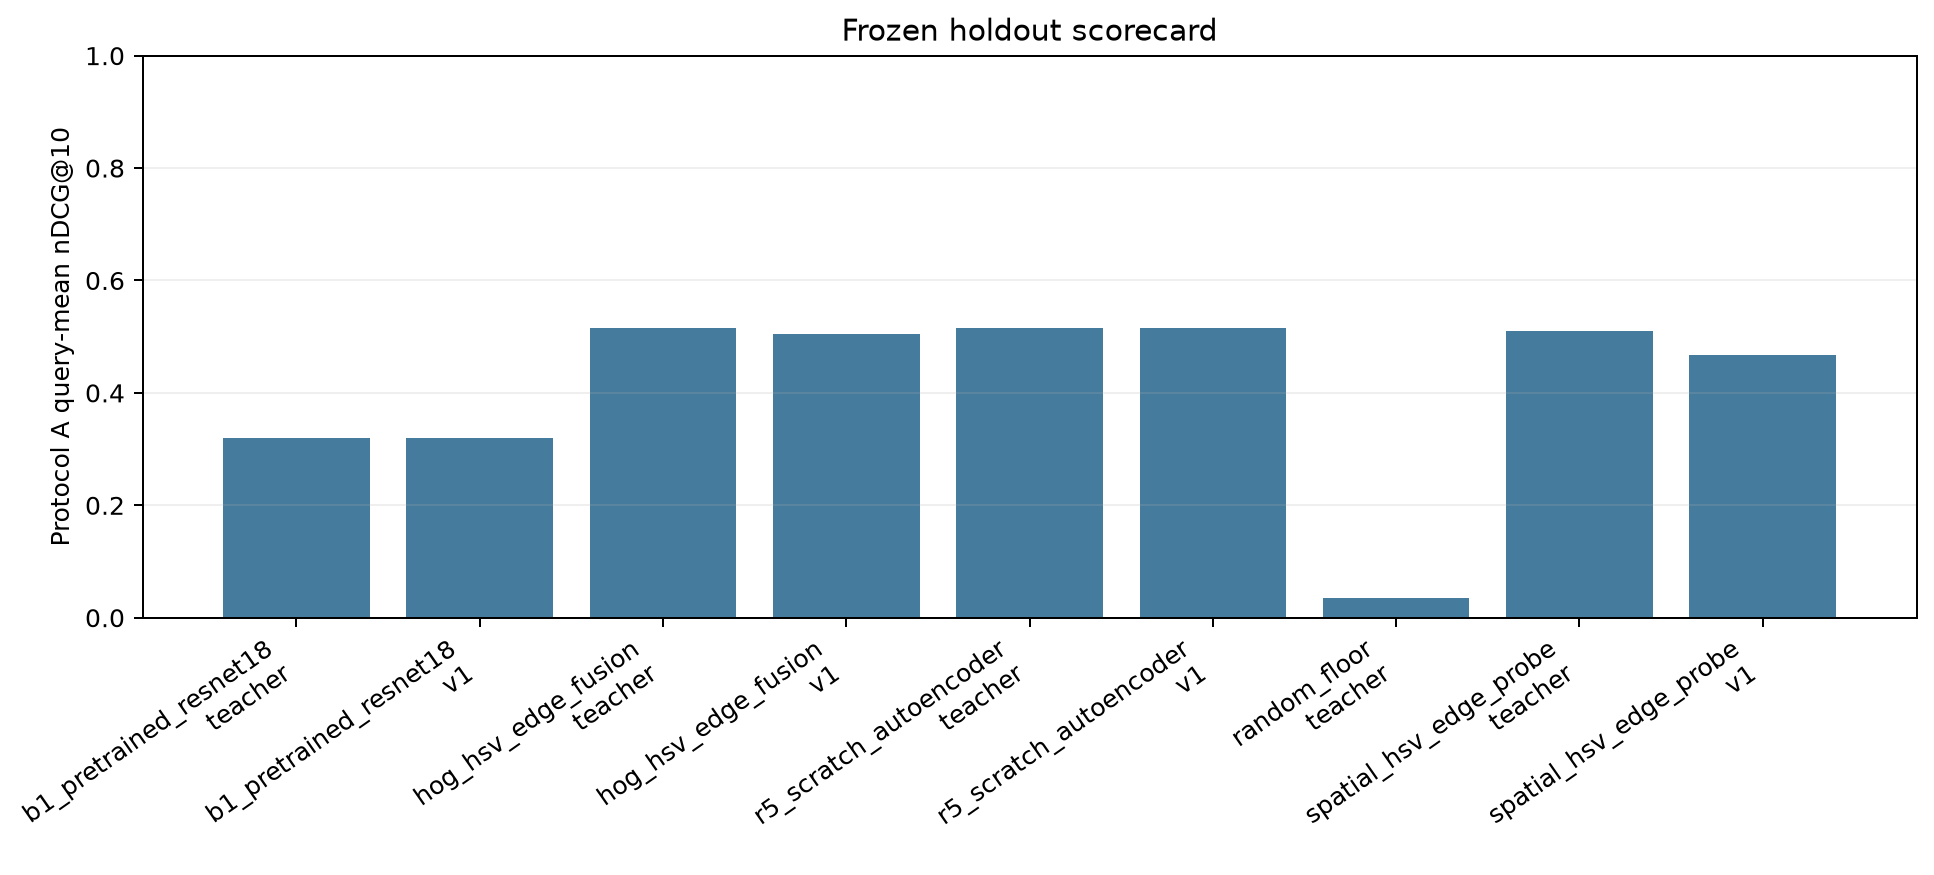

> **How to read this figure.** The teacher-query bars show the frozen primary comparison; V1 bars are source-shift support and B1 remains benchmark-only.

In [6]:
scorecard = pd.read_csv(EVIDENCE / "holdout_scorecard.csv")
scorecard_view = scorecard[
    [
        "method",
        "direction",
        "benchmark_only",
        "ndcg_at_10_query_mean",
        "ndcg_at_10_article_type_macro",
        "precision_any_at_10",
        "precision_strict_at_10",
        "recall_at_10",
        "hit_rate_at_10",
        "tie_rate_at_10",
        "development_reference_ndcg_at_10",
        "development_reference_comparable",
        "holdout_minus_development_ndcg_at_10",
    ]
]
r5_teacher = scorecard.loc[
    scorecard["method"].eq("r5_scratch_autoencoder")
    & scorecard["direction"].eq("teacher")
].iloc[0]
random_teacher = scorecard.loc[scorecard["method"].eq("random_floor")].iloc[0]
assert pd.isna(r5_teacher["holdout_minus_development_ndcg_at_10"])
show_table(
    scorecard_view.round(4),
    "Compare methods first within the teacher direction. The blank development delta is deliberate because the development and holdout columns use different query/gallery estimands.",
)
show_figure(
    FIGURES / "holdout_scorecard.png",
    "The teacher-query bars show the frozen primary comparison; V1 bars are source-shift support and B1 remains benchmark-only.",
    width=900,
)


**Interpretation.**

- **Result:** R5 reaches teacher nDCG@10 0.5162 versus random 0.0343. HOG fusion is close at 0.5151.
- **Meaning:** R5 is far above chance, but the close classical fusion result prevents a claim that learned features clearly dominate every non-pretrained comparator.
- **Decision:** Keep R5 because it was selected before opening and remains the eligible frozen winner.
- **Limitation:** No numeric development-to-holdout delta is reported: development averaged four pairings over 26,217-row fold-1 galleries, while holdout uses teacher queries against one 32,773-row gallery.
- **Trace:** `holdout_scorecard.csv` and `holdout_scorecard.png`.


## 7. Per-class behaviour and error routes

A single mean can hide rare classes. The class table aggregates the same clean R5 query rows, while the route table counts first-result article-type pairings.


In [7]:
per_query_primary = pd.read_csv(EVIDENCE / "holdout_per_query_primary.csv")
error_routes = pd.read_csv(EVIDENCE / "holdout_error_routes.csv")
r5_clean = per_query_primary.loc[
    per_query_primary["method"].eq("r5_scratch_autoencoder")
    & per_query_primary["direction"].eq("teacher")
    & per_query_primary["condition"].eq("clean")
].copy()
class_behaviour = (
    r5_clean.groupby("articleType", as_index=False)
    .agg(queries=("query_id", "size"), mean_nDCG_at_10=("ndcg_at_10", "mean"))
    .sort_values("mean_nDCG_at_10")
)
class_extremes = pd.concat(
    [
        class_behaviour.head(10).assign(band="lowest 10"),
        class_behaviour.tail(10).assign(band="highest 10"),
    ],
    ignore_index=True,
)
mistaken_routes = (
    error_routes.loc[
        error_routes["query_articleType"].ne(error_routes["candidate_articleType"])
    ]
    .sort_values(["count", "mean_ndcg_at_10"], ascending=[False, True])
    .head(15)
)
show_table(
    class_extremes.round(4),
    "Use query count before trusting an extreme mean. Small classes can move sharply from a few cases.",
)
show_table(
    mistaken_routes.round(4),
    "Each row is a directional query-type to first-result-type route. Count gives frequency; mean nDCG shows whether the rest of the top ten partly recovered.",
)


,articleType,queries,mean_nDCG_at_10,band
0,Blazers,1,0.0000,lowest 10
1,Clothing Set,1,0.0000,lowest 10
2,Foundation and Primer,1,0.0000,lowest 10
3,Key chain,1,0.0000,lowest 10
4,Jumpsuit,1,0.0000,lowest 10
5,Nehru Jackets,1,0.0000,lowest 10
6,Tablet Sleeve,1,0.0000,lowest 10
7,Rain Jacket,1,0.0000,lowest 10
8,Shrug,1,0.0000,lowest 10
9,Tights,1,0.0000,lowest 10


> **How to read this table.** Use query count before trusting an extreme mean. Small classes can move sharply from a few cases.

,query_articleType,candidate_articleType,count,mean_ndcg_at_10
22,Shirts,Tshirts,49,0.1921
23,Tshirts,Tops,47,0.2368
25,Tops,Tshirts,44,0.1932
24,Casual Shoes,Sports Shoes,44,0.2791
27,Sports Shoes,Casual Shoes,42,0.3109
31,Tshirts,Shirts,32,0.3272
40,Heels,Flats,19,0.2909
42,Flats,Heels,18,0.1131
45,Dresses,Kurtas,16,0.1045
44,Casual Shoes,Formal Shoes,16,0.3046


> **How to read this table.** Each row is a directional query-type to first-result-type route. Count gives frequency; mean nDCG shows whether the rest of the top ten partly recovered.

**Interpretation.**

- **Result:** Class quality varies materially, and common nearest-result routes include visually or semantically neighbouring article types.
- **Meaning:** Aggregate nDCG is useful for selection but not a promise of equal service across all catalogue classes.
- **Decision:** Monitor low-support and low-nDCG classes separately in any deployment review.
- **Limitation:** Route counts are descriptive; they do not prove why an embedding chose a candidate.
- **Trace:** `holdout_per_query_primary.csv` and `holdout_error_routes.csv`.


## 8. Family-blocked bootstrap intervals

The notebook rebuilds all 10,000 paired family-blocked draws from the frozen clean per-query scores and the hashed blind family map, then checks the saved intervals to 1e-12.


,metric,lower_95,median,upper_95,replicates,random_seed,sampled_group_count
0,r5_mean_ndcg_at_10,0.5076,0.5161,0.5246,10000,2753,4110
1,r5_minus_random_floor_ndcg_at_10,0.4733,0.4818,0.4903,10000,2753,4110
2,r5_minus_spatial_hsv_edge_probe_ndcg_at_10,0.0009,0.0066,0.0121,10000,2753,4110
3,r5_minus_hog_hsv_edge_fusion_ndcg_at_10,-0.0035,0.0011,0.0055,10000,2753,4110
4,r5_minus_b1_pretrained_resnet18_ndcg_at_10,0.1885,0.1968,0.2048,10000,2753,4110


> **How to read this table.** For R5 minus comparator rows, an interval wholly above zero supports a positive R5 effect. Crossing zero means the paired interval does not separate them.

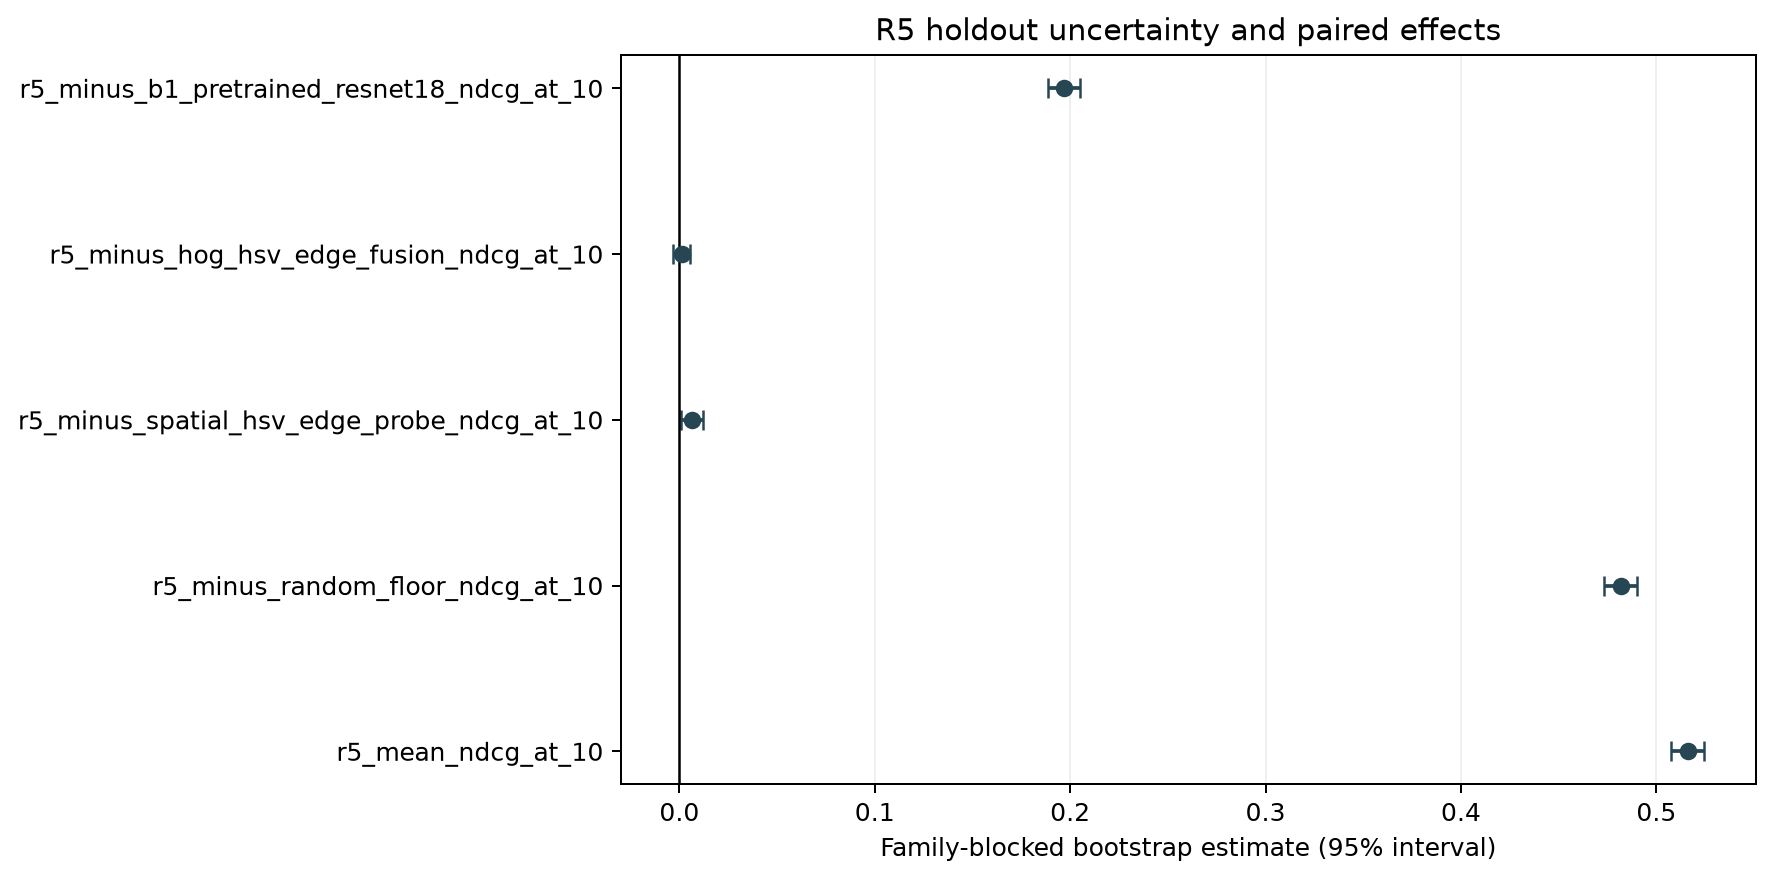

> **How to read this figure.** Dots are paired medians and lines are family-blocked 95% percentile intervals; the vertical zero line is the no-difference reference.

In [8]:
bootstrap_recorded = pd.read_csv(EVIDENCE / "holdout_bootstrap_intervals.csv")
clean = per_query_primary.loc[
    per_query_primary["direction"].eq("teacher")
    & per_query_primary["condition"].eq("clean")
].copy()
query_ids = sorted(
    pd.to_numeric(
        query_manifest.loc[query_manifest["direction"].eq("teacher"), "id"],
        errors="raise",
    )
    .astype(int)
    .tolist()
)
groups_by_id = (
    query_manifest.loc[query_manifest["direction"].eq("teacher")]
    .assign(id=lambda frame: pd.to_numeric(frame["id"], errors="raise").astype(int))
    .set_index("id")["product_family_group"]
)
groups = groups_by_id.loc[query_ids].astype(str).to_numpy()
scores = {}
for method in prediction_receipt["coverage"]["methods"]:
    selected = clean.loc[
        clean["method"].eq(method), ["query_id", "ndcg_at_10"]
    ].copy()
    selected["query_id"] = pd.to_numeric(
        selected["query_id"], errors="raise"
    ).astype(int)
    assert not selected["query_id"].duplicated().any()
    assert set(selected["query_id"]) == set(query_ids)
    scores[method] = (
        selected.set_index("query_id")
        .loc[query_ids, "ndcg_at_10"]
        .to_numpy(dtype=float)
    )

draws = paired_family_ranking_bootstrap(
    scores,
    groups,
    reference="r5_scratch_autoencoder",
    replicates=10_000,
    random_seed=2_753,
)
r5_draws = draws.loc[draws["method"].eq("r5_scratch_autoencoder")]
r5_interval = summarise_ranking_bootstrap(
    r5_draws, value_column="mean_score", random_seed=2_753
)
r5_interval.loc[:, "metric"] = "r5_mean_ndcg_at_10"
interval_frames = [r5_interval]
for comparator in prediction_receipt["coverage"]["methods"]:
    if comparator == "r5_scratch_autoencoder":
        continue
    comparison = draws.loc[draws["method"].eq(comparator)].copy()
    comparison["r5_minus_comparator"] = -comparison["mean_minus_reference"]
    interval = summarise_ranking_bootstrap(
        comparison,
        value_column="r5_minus_comparator",
        random_seed=2_753,
    )
    interval.loc[:, "metric"] = f"r5_minus_{comparator}_ndcg_at_10"
    interval_frames.append(interval)
bootstrap_recomputed = pd.concat(interval_frames, ignore_index=True)

recorded_ordered = bootstrap_recorded.sort_values("metric").reset_index(drop=True)
recomputed_ordered = bootstrap_recomputed.sort_values("metric").reset_index(drop=True)
assert recomputed_ordered["metric"].tolist() == recorded_ordered["metric"].tolist()
np.testing.assert_allclose(
    recomputed_ordered[["lower_95", "median", "upper_95"]].to_numpy(dtype=float),
    recorded_ordered[["lower_95", "median", "upper_95"]].to_numpy(dtype=float),
    rtol=0.0,
    atol=1e-12,
)
show_table(
    bootstrap_recorded.round(4),
    "For R5 minus comparator rows, an interval wholly above zero supports a positive R5 effect. Crossing zero means the paired interval does not separate them.",
)
show_figure(
    FIGURES / "holdout_bootstrap_intervals.png",
    "Dots are paired medians and lines are family-blocked 95% percentile intervals; the vertical zero line is the no-difference reference.",
    width=900,
)


**Interpretation.**

- **Result:** R5 minus random is [0.4733, 0.4903], while R5 minus HOG fusion is [-0.0035, 0.0055] and crosses zero.
- **Meaning:** R5 is clearly above random and the spatial probe. The interval does not separate R5 and HOG; small effects in either direction remain possible.
- **Decision:** Keep the preselected R5; report the unresolved R5–HOG difference instead of turning the tiny point gap into a win claim.
- **Limitation:** The pre-declared analysis is an effect size with a paired family-blocked 95% interval. A p-value would require a separate null-generating test declared before the unlock, and counting bootstrap draws below zero is not silently relabelled as a p-value.
- **Trace:** Recomputed from `holdout_per_query_primary.csv` plus the hashed blind family map and checked exactly against `holdout_bootstrap_intervals.csv`; figure: `holdout_bootstrap_intervals.png`.


## 9. Distance-threshold selective retrieval

This diagnostic asks what happens when queries with larger nearest-neighbour cosine distances are withheld.


,target_coverage,actual_coverage,distance_threshold,retained_queries,selective_ndcg_at_10,selective_recall_at_10,boundary_note
0,1.0,1.0000,0.5446,5778,0.5162,0.3779,retained_queries is authoritative when rank-1 ...
1,0.9,0.9001,0.2657,5201,0.5357,0.3844,retained_queries is authoritative when rank-1 ...
2,0.8,0.8001,0.2245,4623,0.5469,0.3899,retained_queries is authoritative when rank-1 ...
3,0.7,0.7001,0.1961,4045,0.5573,0.3967,retained_queries is authoritative when rank-1 ...
4,0.5,0.5000,0.1530,2889,0.5779,0.4202,retained_queries is authoritative when rank-1 ...
5,0.3,0.3001,0.1122,1734,0.5999,0.4568,retained_queries is authoritative when rank-1 ...


> **How to read this table.** Moving downward keeps fewer queries with smaller nearest distances. Compare actual coverage, retained count, nDCG, and recall together.

,family_queries,family_recall_defined
0,5778,2280


> **How to read this table.** Family recall exists only when the fixed gallery contains an eligible same-family product.

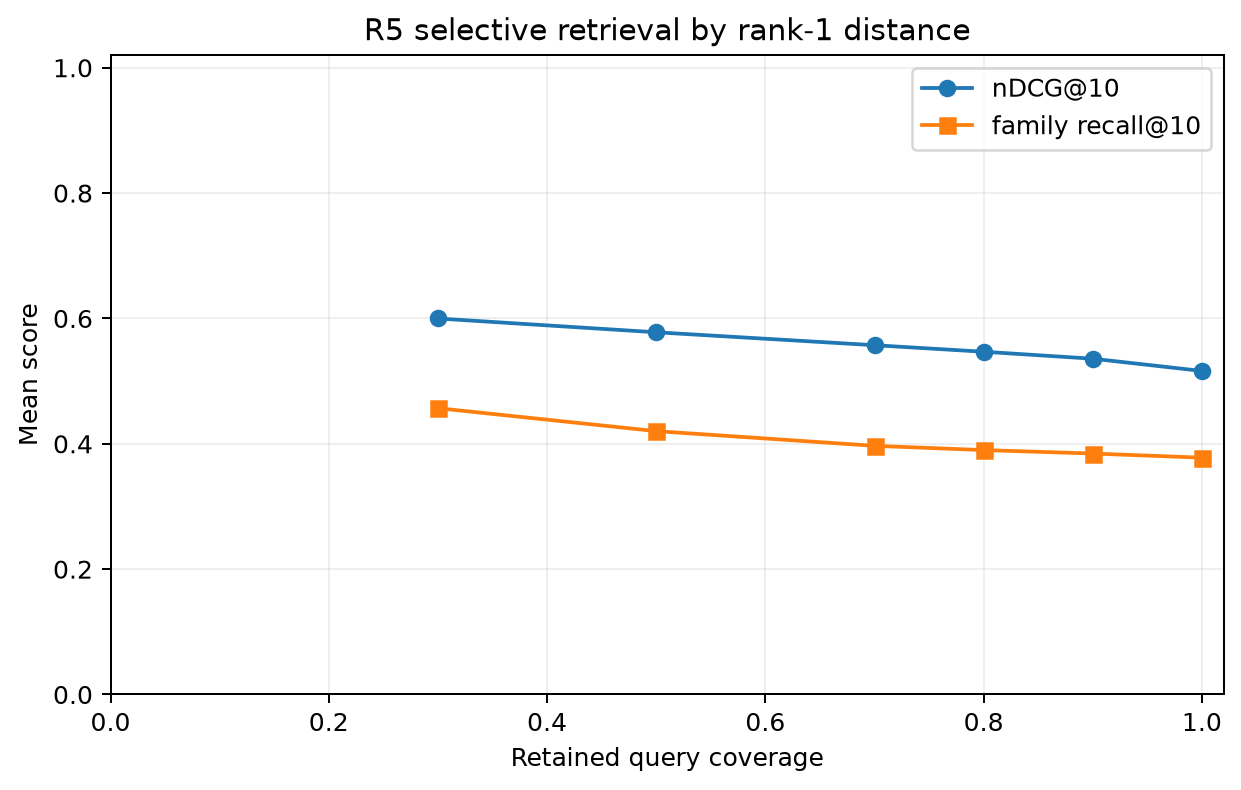

> **How to read this figure.** The curve describes a quality-coverage trade-off on this opened holdout; it is not a chosen service rule.

In [9]:
selective = pd.read_csv(EVIDENCE / "holdout_selective_retrieval.csv")
per_query_family = pd.read_csv(EVIDENCE / "holdout_per_query_family.csv")
family_coverage = pd.DataFrame(
    [
        {
            "family_queries": len(
                per_query_family.loc[
                    per_query_family["method"].eq("r5_scratch_autoencoder")
                    & per_query_family["direction"].eq("teacher")
                ]
            ),
            "family_recall_defined": int(
                per_query_family.loc[
                    per_query_family["method"].eq("r5_scratch_autoencoder")
                    & per_query_family["direction"].eq("teacher"),
                    "recall_at_10",
                ].notna().sum()
            ),
        }
    ]
)
show_table(
    selective.round(4),
    "Moving downward keeps fewer queries with smaller nearest distances. Compare actual coverage, retained count, nDCG, and recall together.",
)
show_table(
    family_coverage,
    "Family recall exists only when the fixed gallery contains an eligible same-family product.",
)
show_figure(
    FIGURES / "holdout_selective_retrieval.png",
    "The curve describes a quality-coverage trade-off on this opened holdout; it is not a chosen service rule.",
    width=850,
)


**Interpretation.**

- **Result:** nDCG rises from 0.5162 at full coverage to 0.5999 near 30% coverage.
- **Meaning:** Rank-1 distance contains useful difficulty information, but improved retained-set quality comes from declining many queries.
- **Decision:** No production threshold is chosen from holdout data. A threshold needs a separate development or business calibration set.
- **Limitation:** Distance ties make retained query count authoritative, and production query frequencies may differ from this holdout.
- **Trace:** `holdout_selective_retrieval.csv`, `holdout_per_query_family.csv`, and `holdout_selective_retrieval.png`.


## 10. Development and EDA expectations

Pre-holdout expectations are checked against frozen evidence rather than repeated as facts. Source ratios are labelled as different estimands.


,expectation,holdout evidence,status
0,R5 should remain far above random,paired interval wholly above zero,supported
1,R5 should clearly beat HOG fusion,paired interval crosses zero,not separated
2,rare article types should be harder,rare-type nDCG 0.4515 versus overall 0.5162,supported
3,grayscale should be harder,0.6736 on only 49 queries,"contradicted, small slice"
4,R5 should transfer from teacher to V1 images,holdout ratio 0.9980,supported in holdout definition
5,large blank canvases remain risky,wide and tall deltas are strongly negative,supported


> **How to read this table.** Status says whether the opened holdout supported the earlier direction. Small slices and different estimands limit the strength of that statement.

,method,holdout_ratio_definition,teacher_to_teacher_ndcg_at_10,v1_to_teacher_gallery_ndcg_at_10,holdout_source_robustness_ratio,status,development_source_robustness_ratio,development_ratio_comparable,development_ratio_basis
0,r5_scratch_autoencoder,v1_to_teacher_gallery / teacher_to_teacher_gal...,0.5162,0.5152,0.9980,measured,0.9998,False,development used four source pairings and two ...
1,random_floor,not_applicable,0.0343,NaN,NaN,not_applicable_source_independent_single_froze...,NaN,NaN,NaN
2,spatial_hsv_edge_probe,v1_to_teacher_gallery / teacher_to_teacher_gal...,0.5096,0.4671,0.9165,measured,NaN,NaN,NaN
3,hog_hsv_edge_fusion,v1_to_teacher_gallery / teacher_to_teacher_gal...,0.5151,0.5045,0.9793,measured,NaN,NaN,NaN
4,b1_pretrained_resnet18,v1_to_teacher_gallery / teacher_to_teacher_gal...,0.3195,0.3195,1.0000,measured,NaN,NaN,NaN


> **How to read this table.** Holdout ratio is V1 queries over teacher queries against one teacher gallery. The R5 development ratio used four pairings and two fold-1 galleries, so the two numbers are related but not directly subtractable.

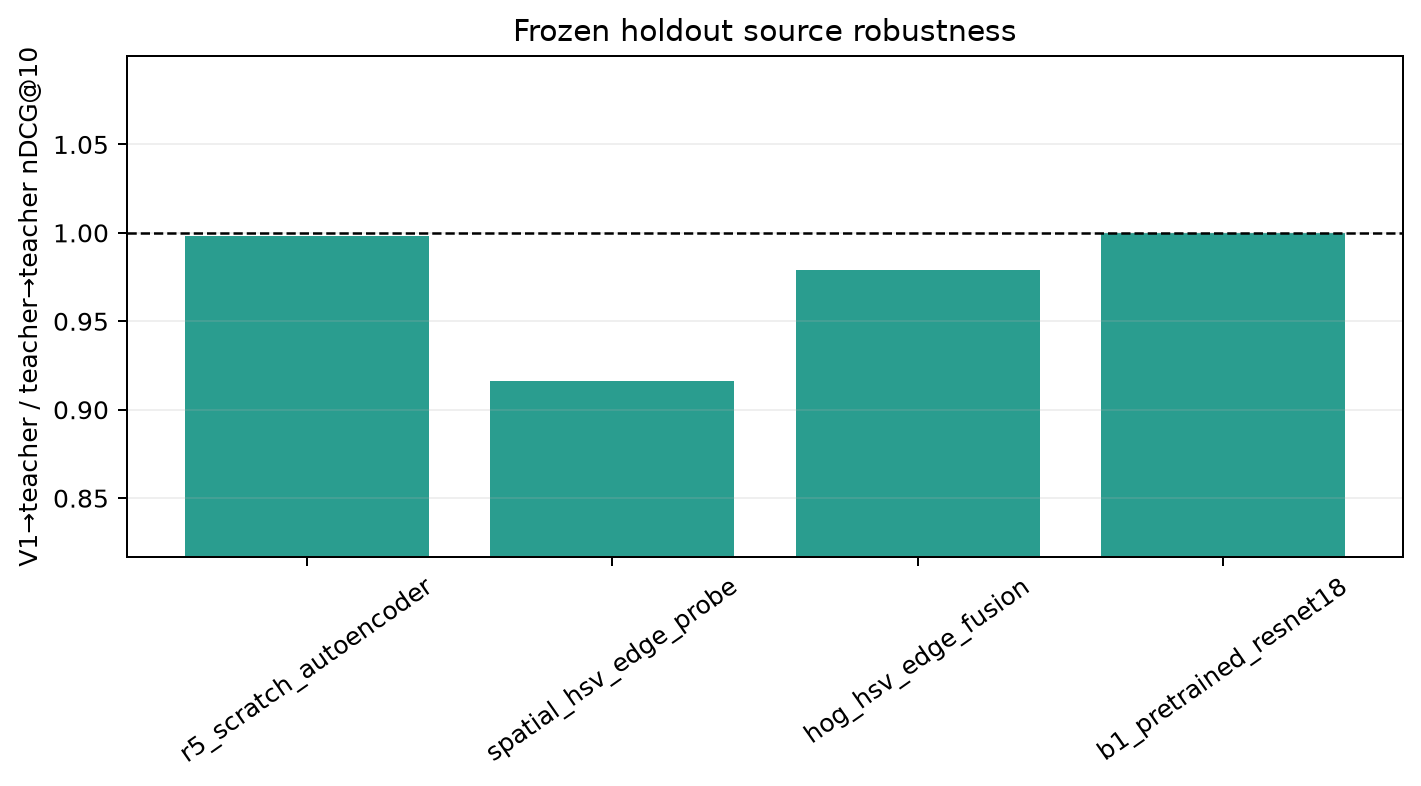

> **How to read this figure.** Ratios near one mean little source loss under the holdout definition; random has no ratio because its one frozen ranking is source-independent.

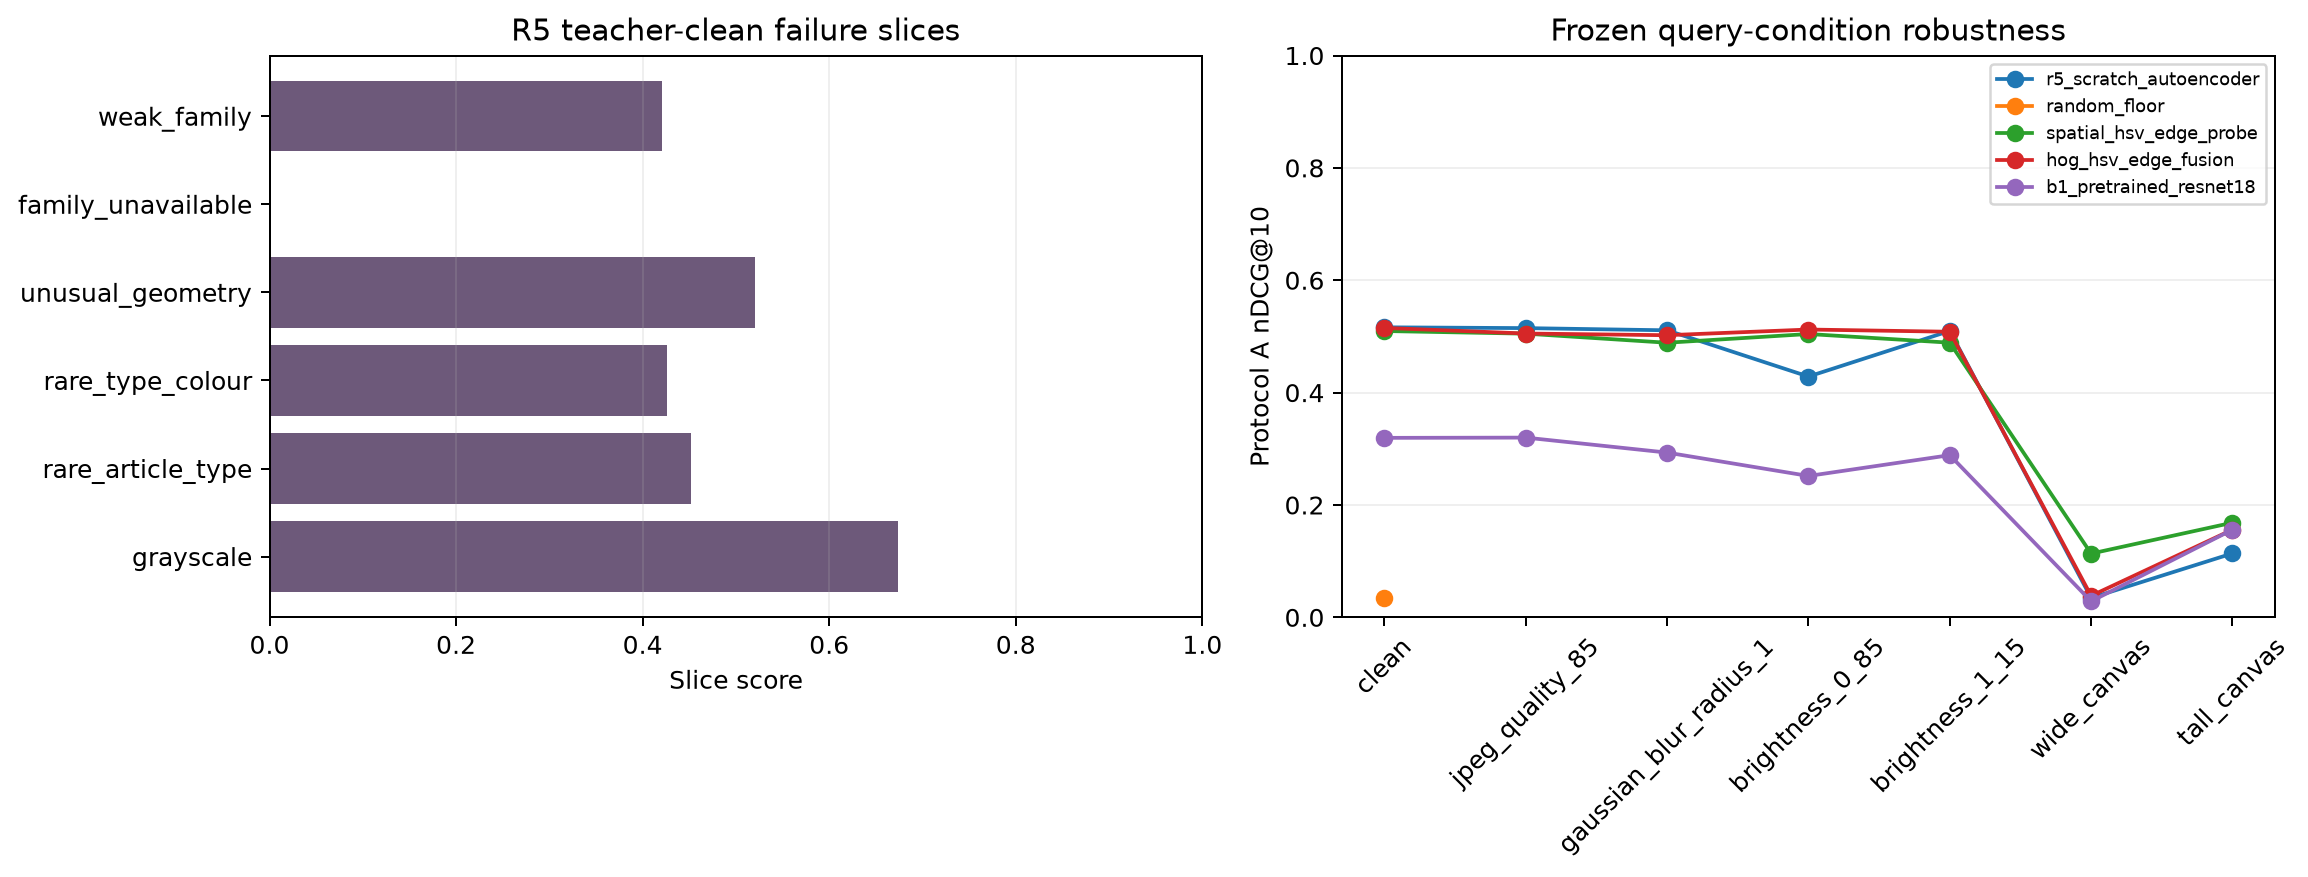

> **How to read this figure.** Read slice scores with their sample sizes and condition deltas; neither panel is a causal estimate.

In [10]:
slices = pd.read_csv(EVIDENCE / "holdout_slice_metrics.csv")
source_robustness = pd.read_csv(EVIDENCE / "holdout_source_robustness.csv")
r5_source = source_robustness.loc[
    source_robustness["method"].eq("r5_scratch_autoencoder")
].iloc[0]
r5_robustness_preview = pd.read_csv(
    EVIDENCE / "holdout_robustness_metrics.csv"
)
r5_robustness_preview = r5_robustness_preview.loc[
    r5_robustness_preview["method"].eq("r5_scratch_autoencoder")
]
expectation_checks = pd.DataFrame(
    [
        {
            "expectation": "R5 should remain far above random",
            "holdout evidence": "paired interval wholly above zero",
            "status": "supported",
        },
        {
            "expectation": "R5 should clearly beat HOG fusion",
            "holdout evidence": "paired interval crosses zero",
            "status": "not separated",
        },
        {
            "expectation": "rare article types should be harder",
            "holdout evidence": "rare-type nDCG 0.4515 versus overall 0.5162",
            "status": "supported",
        },
        {
            "expectation": "grayscale should be harder",
            "holdout evidence": "0.6736 on only 49 queries",
            "status": "contradicted, small slice",
        },
        {
            "expectation": "R5 should transfer from teacher to V1 images",
            "holdout evidence": f"holdout ratio {r5_source['holdout_source_robustness_ratio']:.4f}",
            "status": "supported in holdout definition",
        },
        {
            "expectation": "large blank canvases remain risky",
            "holdout evidence": "wide and tall deltas are strongly negative",
            "status": "supported",
        },
    ]
)
show_table(
    expectation_checks,
    "Status says whether the opened holdout supported the earlier direction. Small slices and different estimands limit the strength of that statement.",
)
show_table(
    source_robustness.round(4),
    "Holdout ratio is V1 queries over teacher queries against one teacher gallery. The R5 development ratio used four pairings and two fold-1 galleries, so the two numbers are related but not directly subtractable.",
)
show_figure(
    FIGURES / "holdout_source_robustness.png",
    "Ratios near one mean little source loss under the holdout definition; random has no ratio because its one frozen ranking is source-independent.",
    width=850,
)
show_figure(
    FIGURES / "holdout_slices_robustness.png",
    "Read slice scores with their sample sizes and condition deltas; neither panel is a causal estimate.",
    width=950,
)


**Interpretation.**

- **Result:** R5's holdout source ratio is 0.9980, rare classes are weaker, grayscale is unexpectedly strong on 49 cases, and blank canvases remain severe failures.
- **Meaning:** The broad source-transfer expectation held, but HOG parity and slice reversals add evidence that development alone did not reveal.
- **Decision:** Preserve source-specific normalization and add canvas checks to operational monitoring.
- **Limitation:** The development ratio 0.9998 and holdout ratio 0.9980 use different galleries, query sets, and pairing formulas, so this is not a like-for-like delta.
- **Trace:** `holdout_slice_metrics.csv`, `holdout_source_robustness.csv`, `holdout_source_robustness.png`, and `holdout_slices_robustness.png`.


## 11. Seven query conditions

Every predeclared condition is shown for R5. The gallery stays clean; only teacher queries receive these deterministic changes.


In [11]:
robustness = pd.read_csv(EVIDENCE / "holdout_robustness_metrics.csv")
conditions = prediction_receipt["coverage"]["conditions"]
assert conditions == [
    "clean",
    "jpeg_quality_85",
    "gaussian_blur_radius_1",
    "brightness_0_85",
    "brightness_1_15",
    "wide_canvas",
    "tall_canvas",
]
r5_robustness = robustness.loc[
    robustness["method"].eq("r5_scratch_autoencoder")
].copy()
assert r5_robustness["condition"].tolist() == conditions
show_table(
    r5_robustness.round(4),
    "Delta is condition nDCG minus clean nDCG. Top-10 overlap measures how much the returned set changed, while tie rate checks equal-distance behaviour.",
)


,method,condition,ndcg_at_10,delta_vs_clean,mean_top10_overlap_with_clean,tie_rate_at_10,status
0,r5_scratch_autoencoder,clean,0.5162,0.0000,1.0000,0.0319,measured
1,r5_scratch_autoencoder,jpeg_quality_85,0.5148,-0.0014,0.9711,0.0317,measured
2,r5_scratch_autoencoder,gaussian_blur_radius_1,0.5109,-0.0053,0.8071,0.0318,measured
3,r5_scratch_autoencoder,brightness_0_85,0.4286,-0.0877,0.4666,0.0275,measured
4,r5_scratch_autoencoder,brightness_1_15,0.5098,-0.0064,0.7880,0.0301,measured
5,r5_scratch_autoencoder,wide_canvas,0.0345,-0.4817,0.0011,0.0088,measured
6,r5_scratch_autoencoder,tall_canvas,0.1138,-0.4024,0.0111,0.0801,measured


> **How to read this table.** Delta is condition nDCG minus clean nDCG. Top-10 overlap measures how much the returned set changed, while tie rate checks equal-distance behaviour.

**Interpretation.**

- **Result:** JPEG changes little (-0.0014), blur and brightening are modest, darkening loses 0.0877, and wide/tall canvases lose 0.4817/0.4024.
- **Meaning:** Small pixel changes are not the main weakness; content scale inside a large blank canvas is.
- **Decision:** Require crop or content-scale checks before accepting arbitrary uploads.
- **Limitation:** These seven synthetic conditions do not estimate how often each problem occurs in real traffic.
- **Trace:** `holdout_robustness_metrics.csv`; the exact seven-condition order comes from the blind receipt.


## 12. Errors and explainability limits

Six deterministic zero-nDCG examples make failures inspectable. They are evidence of what was retrieved, not a causal explanation of the embedding.


,query_id,query_articleType,query_baseColour,candidate_id,candidate_articleType,candidate_baseColour,distance,ndcg_at_10
0,1579,Jackets,Grey,2101,Shirts,Blue,0.1864,0
1,1918,Backpacks,Blue,43293,Handbags,Blue,0.2724,0
2,2630,Flats,Red,45370,Heels,Brown,0.1612,0
3,2663,Handbags,Brown,9572,Travel Accessory,Black,0.3343,0
4,2701,Tops,Yellow,22599,Tshirts,Yellow,0.4015,0
5,3823,Sandals,White,3824,Flip Flops,Brown,0.2840,0


> **How to read this table.** Compare the query and nearest candidate metadata, then remember that one candidate does not summarize all ten ranks.

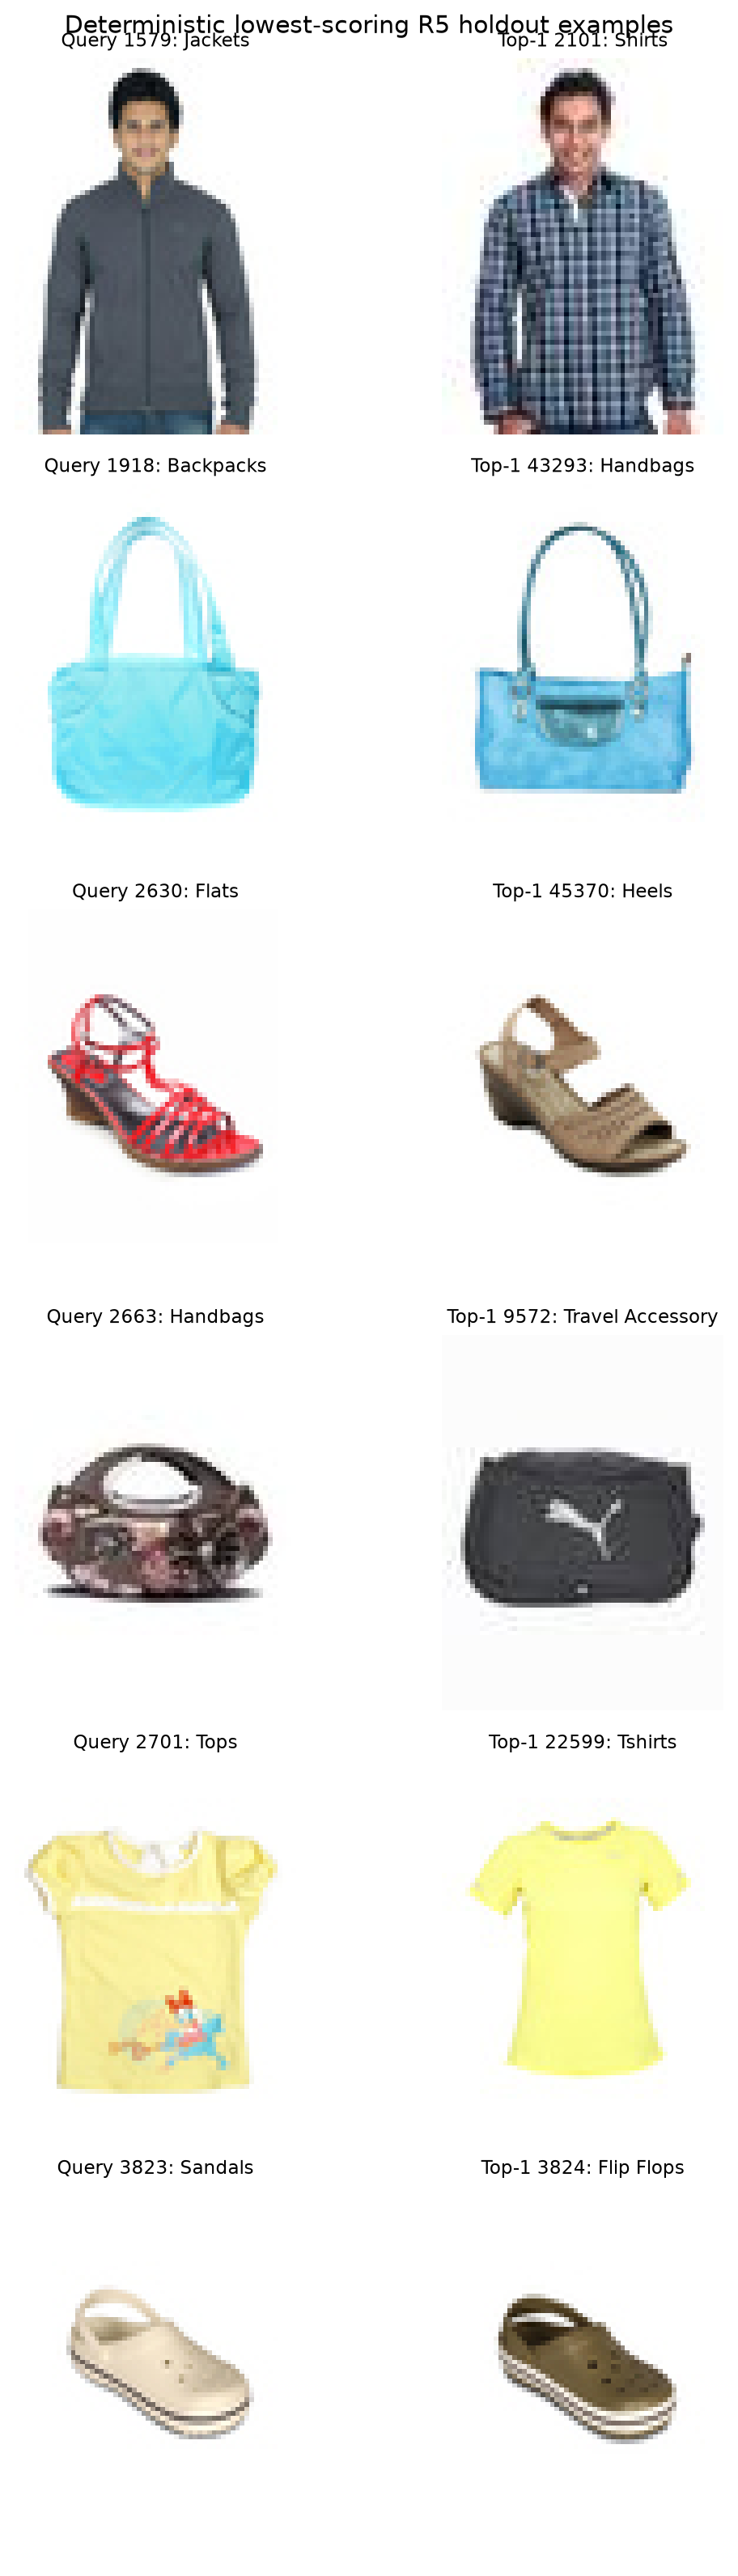

> **How to read this figure.** Each pair is a selected failure. Visual similarity can coexist with metadata disagreement, so the image does not by itself identify the cause.

In [12]:
error_examples = pd.read_csv(EVIDENCE / "holdout_error_examples.csv")
show_table(
    error_examples[
        [
            "query_id",
            "query_articleType",
            "query_baseColour",
            "candidate_id",
            "candidate_articleType",
            "candidate_baseColour",
            "distance",
            "ndcg_at_10",
        ]
    ].round(4),
    "Compare the query and nearest candidate metadata, then remember that one candidate does not summarize all ten ranks.",
)
show_figure(
    FIGURES / "holdout_error_examples.png",
    "Each pair is a selected failure. Visual similarity can coexist with metadata disagreement, so the image does not by itself identify the cause.",
    width=1000,
)


**Interpretation.**

- **Result:** Zero-nDCG examples include jackets-to-shirts, backpacks-to-handbags, flats-to-heels, and neighbouring footwear or accessory confusions.
- **Meaning:** Some failures are visually plausible even when the declared metadata relevance gives zero credit.
- **Decision:** Use examples to create review questions, not to rewrite the metric after seeing holdout outcomes.
- **Limitation:** Nearest-neighbour pictures and distances are post-hoc descriptions. They do not prove which pixels caused the embedding or whether a human would prefer the labelled match.
- **Trace:** `holdout_error_examples.csv`, `holdout_error_examples.png`, and the broader route counts in `holdout_error_routes.csv`.


## 13. Cost and operation

The deployment record measures one local CPU path and the frozen package sizes. It is useful for planning, not a universal service-level promise.


In [13]:
cost = deployment_summary.copy()
cost["model_package_MB"] = cost["model_package_bytes"] / 1_000_000
cost["gallery_MB"] = cost["gallery_bytes"] / 1_000_000
cost_view = cost[
    [
        "method",
        "parameter_count",
        "model_package_MB",
        "gallery_MB",
        "timed_queries",
        "single_query_cpu_p50_ms",
        "single_query_cpu_p95_ms",
    ]
]
show_table(
    cost_view.round(3),
    "Package and gallery sizes are decimal megabytes. Latency is the median and 95th percentile across eight local single-query CPU timings.",
)


,method,parameter_count,model_package_MB,gallery_MB,timed_queries,single_query_cpu_p50_ms,single_query_cpu_p95_ms
0,r5_scratch_autoencoder,14276931,57.196,24.421,8,23.389,24.903


> **How to read this table.** Package and gallery sizes are decimal megabytes. Latency is the median and 95th percentile across eight local single-query CPU timings.

**Interpretation.**

- **Result:** The package is about 57.20 MB, the gallery about 24.42 MB, and local CPU p50/p95 are 23.39/24.90 ms.
- **Meaning:** Exact cosine search with the fixed gallery is practical on this measured machine.
- **Decision:** Record hardware, concurrency, preprocessing, and catalogue size with every future latency claim.
- **Limitation:** Eight local queries do not model network time, concurrent users, cold starts, or a changing catalogue.
- **Trace:** `deployment_summary.csv` and the frozen model/gallery provenance in Section 2.


## 14. Academic foundations and published-work boundary

Papers justify methods and evaluation choices. Project artifacts, not outside scores, justify this project's result.


In [14]:
training_literature = pd.DataFrame(
    [
        {
            "paper": "Dalal & Triggs (2005)",
            "idea used here": "HOG descriptor in classical comparisons",
            "source": "https://lear.inrialpes.fr/people/triggs/pubs/Dalal-cvpr05.pdf",
            "boundary": "Human detection paper; no fashion score transfers",
        },
        {
            "paper": "He et al. (2016)",
            "idea used here": "Residual backbone for scratch candidates and B1",
            "source": "https://openaccess.thecvf.com/content_cvpr_2016/html/He_Deep_Residual_Learning_CVPR_2016_paper.html",
            "boundary": "Architecture source; B1's pretrained weights are comparison-only",
        },
        {
            "paper": "Bardes et al. (2022)",
            "idea used here": "VICReg objective in R1-R4",
            "source": "https://openreview.net/forum?id=xm6YD62D1Ub",
            "boundary": "Motivation only; measured project evidence selected R5",
        },
    ]
)
evaluation_literature = pd.DataFrame(
    [
        {
            "paper": "Järvelin & Kekäläinen (2002)",
            "idea used here": "graded cumulative gain and nDCG",
            "source": "https://doi.org/10.1145/582415.582418",
            "boundary": "Metric foundation; this relevance grading is project-specific",
        },
        {
            "paper": "Field & Welsh (2007)",
            "idea used here": "cluster bootstrap",
            "source": "https://doi.org/10.1111/j.1467-9868.2007.00593.x",
            "boundary": "Product-family groups are conservative proxies",
        },
        {
            "paper": "Geifman & El-Yaniv (2017)",
            "idea used here": "selective prediction",
            "source": "https://papers.neurips.cc/paper_files/paper/2017/hash/4a8423d5e91fda00bb7e46540e2b0cf1-Abstract.html",
            "boundary": "Diagnostic curve does not choose a business threshold",
        },
        {
            "paper": "Hendrycks & Dietterich (2019)",
            "idea used here": "common-corruption robustness",
            "source": "https://arxiv.org/abs/1903.12261",
            "boundary": "Synthetic condition frequency is not production frequency",
        },
    ]
)
published_comparison = pd.DataFrame(
    [
        {
            "work": "This project",
            "data and task": "38,612 catalogue products; metadata-graded Top-10 retrieval",
            "query/gallery": "teacher and V1 holdout queries; one development teacher gallery",
            "reported measure": "linear nDCG@10",
            "weight origin": "submitted R5 trained from scratch",
            "directly comparable": "self only",
        },
        {
            "work": "DeepFashion — Liu et al. (2016)",
            "data and task": "different large fashion corpus and consumer-to-shop benchmark",
            "query/gallery": "paper-specific consumer/shop split",
            "reported measure": "paper-specific top-k retrieval measures",
            "weight origin": "pretrained backbone",
            "directly comparable": "no",
        },
        {
            "work": "Street2Shop — Kiapour et al. (2015)",
            "data and task": "street photos matched to exact shop items",
            "query/gallery": "paper-specific street/shop split",
            "reported measure": "paper-specific top-k retrieval accuracy",
            "weight origin": "pretrained backbone",
            "directly comparable": "no",
        },
    ]
)
show_table(
    training_literature,
    "These papers explain already-completed method choices. They do not retrain a model or validate the holdout result.",
)
show_table(
    evaluation_literature,
    "These papers motivate measurement design. Each boundary states what cannot be transferred.",
)
show_table(
    published_comparison,
    "Compare protocols, not score size. 'No' means the data, relevance rule, metric, or weight origin differs.",
)


,paper,idea used here,source,boundary
0,Dalal & Triggs (2005),HOG descriptor in classical comparisons,https://lear.inrialpes.fr/people/triggs/pubs/D...,Human detection paper; no fashion score transfers
1,He et al. (2016),Residual backbone for scratch candidates and B1,https://openaccess.thecvf.com/content_cvpr_201...,Architecture source; B1's pretrained weights a...
2,Bardes et al. (2022),VICReg objective in R1-R4,https://openreview.net/forum?id=xm6YD62D1Ub,Motivation only; measured project evidence sel...


> **How to read this table.** These papers explain already-completed method choices. They do not retrain a model or validate the holdout result.

,paper,idea used here,source,boundary
0,Järvelin & Kekäläinen (2002),graded cumulative gain and nDCG,https://doi.org/10.1145/582415.582418,Metric foundation; this relevance grading is p...
1,Field & Welsh (2007),cluster bootstrap,https://doi.org/10.1111/j.1467-9868.2007.00593.x,Product-family groups are conservative proxies
2,Geifman & El-Yaniv (2017),selective prediction,https://papers.neurips.cc/paper_files/paper/20...,Diagnostic curve does not choose a business th...
3,Hendrycks & Dietterich (2019),common-corruption robustness,https://arxiv.org/abs/1903.12261,Synthetic condition frequency is not productio...


> **How to read this table.** These papers motivate measurement design. Each boundary states what cannot be transferred.

,work,data and task,query/gallery,reported measure,weight origin,directly comparable
0,This project,"38,612 catalogue products; metadata-graded Top...",teacher and V1 holdout queries; one developmen...,linear nDCG@10,submitted R5 trained from scratch,self only
1,DeepFashion — Liu et al. (2016),different large fashion corpus and consumer-to...,paper-specific consumer/shop split,paper-specific top-k retrieval measures,pretrained backbone,no
2,Street2Shop — Kiapour et al. (2015),street photos matched to exact shop items,paper-specific street/shop split,paper-specific top-k retrieval accuracy,pretrained backbone,no


> **How to read this table.** Compare protocols, not score size. 'No' means the data, relevance rule, metric, or weight origin differs.

**Interpretation.**

- **Result:** The literature supports HOG, residual models, VICReg, nDCG, blocked resampling, selective retrieval, and corruption checks.
- **Meaning:** Published fashion systems provide context for problem design, not a common leaderboard.
- **Decision:** Do not rank this project's 0.5162 against a DeepFashion or Street2Shop number.
- **Limitation:** DeepFashion and Street2Shop report on different data, different relevance definitions, and pretrained backbones, so no ranking against this project's figure is valid.
- **Trace:** The tables link the primary method papers and state each transfer boundary explicitly.


## 15. Ultimate judgement and artifact audit

The last section checks that every scored artifact and figure named by the complete ledger is present, then states the decision with its main limits.


In [15]:
coverage = pd.read_csv(EVIDENCE / "holdout_coverage.csv")
holdout_metrics = read_json(EVIDENCE / "holdout_metrics.json")
ultimate_judgement = read_json(EVIDENCE / "ultimate_judgement.json")

artifact_audit = pd.DataFrame(
    [
        {
            "artifact": name,
            "path": record["path"],
            "rows": record.get("rows"),
            "bytes": record["bytes"],
            "sha256": record["sha256"],
        }
        for name, record in evaluation_manifest["artifacts"].items()
    ]
).sort_values("artifact")
expected_scored = {
    "deployment_summary.csv",
    "holdout_bootstrap_intervals.csv",
    "holdout_coverage.csv",
    "holdout_error_examples.csv",
    "holdout_error_routes.csv",
    "holdout_metrics.json",
    "holdout_per_query_family.csv",
    "holdout_per_query_primary.csv",
    "holdout_robustness_metrics.csv",
    "holdout_scorecard.csv",
    "holdout_selective_retrieval.csv",
    "holdout_slice_metrics.csv",
    "holdout_source_robustness.csv",
    "ultimate_judgement.json",
}
recorded_names = {Path(path).name for path in artifact_audit["path"]}
assert expected_scored.issubset(recorded_names)
assert len(artifact_audit) == 20
assert sum(name.startswith("figure_") for name in artifact_audit["artifact"]) == 6
assert holdout_metrics["evaluation_id"] == evaluation_manifest["evaluation_id"]
assert ultimate_judgement["submitted_model"] == "r5_scratch_autoencoder"
assert ultimate_judgement["submitted_model_scratch"] is True

judgement_table = pd.DataFrame(
    [
        {"question": "Submitted model", "answer": ultimate_judgement["judgement"]},
        {"question": "Teacher nDCG@10", "answer": f"{r5_teacher['ndcg_at_10_query_mean']:.4f}"},
        {"question": "Random nDCG@10", "answer": f"{random_teacher['ndcg_at_10_query_mean']:.4f}"},
        {
            "question": "R5 - random 95% interval",
            "answer": "[0.4733, 0.4903]",
        },
        {
            "question": "R5 - HOG fusion 95% interval",
            "answer": "[-0.0035, 0.0055]. The interval does not separate R5 and HOG; small effects in either direction remain possible.",
        },
        {"question": "Coverage audit rows", "answer": len(coverage)},
        {"question": "Verified scored artifacts and figures", "answer": len(artifact_audit)},
        {"question": "Retuning allowed", "answer": ultimate_judgement["retuning_allowed"]},
    ]
)
show_table(
    judgement_table,
    "Read the selected model together with the effect intervals, coverage, and no-retuning boundary.",
)
show_table(
    artifact_audit,
    "The complete ledger contains 14 scored evidence files and six figures. The gateway already checked every listed SHA-256 and byte count.",
)


,question,answer
0,Submitted model,R5 remains the submitted scratch model
1,Teacher nDCG@10,0.5162
2,Random nDCG@10,0.0343
3,R5 - random 95% interval,"[0.4733, 0.4903]"
4,R5 - HOG fusion 95% interval,"[-0.0035, 0.0055]. The interval does not separ..."
5,Coverage audit rows,6
6,Verified scored artifacts and figures,20
7,Retuning allowed,False


> **How to read this table.** Read the selected model together with the effect intervals, coverage, and no-retuning boundary.

,artifact,path,rows,bytes,sha256
0,deployment_summary,results/evidence/task4/final_evaluation/deploy...,1.0,209,4b47d2d26b69a4acf86a89e273f27e562907f60a4a21b6...
1,figure_holdout_bootstrap_intervals,results/figures/task4/final_evaluation/holdout...,NaN,71965,46b0161d1bac24b123a08bb76694285aadc4fb30b12928...
2,figure_holdout_error_examples,results/figures/task4/final_evaluation/holdout...,NaN,191166,9749de346452d0016682f16600a07d744ed2755592fff1...
3,figure_holdout_scorecard,results/figures/task4/final_evaluation/holdout...,NaN,112444,5fb429b5adab7cf0c0769e5075412e4f8a11d731b9394c...
4,figure_holdout_selective_retrieval,results/figures/task4/final_evaluation/holdout...,NaN,54240,70cff9ae88ff597c7e5f8cbb8e70956377093518246bc0...
5,figure_holdout_slices_robustness,results/figures/task4/final_evaluation/holdout...,NaN,165435,83409be58f697f396c355b6995c67f2f72608e6683b78e...
6,figure_holdout_source_robustness,results/figures/task4/final_evaluation/holdout...,NaN,75242,3a6c8d6733d9534f96f007d579f294ac932c97a2baf0fb...
7,holdout_bootstrap_intervals,results/evidence/task4/final_evaluation/holdou...,5.0,646,e8e87397cf2ac141e99ea6f178c86cdb9dac8cd13becbe...
8,holdout_coverage,results/evidence/task4/final_evaluation/holdou...,6.0,302,bd679d0f31c83179cbe500c0d9b64cf12b86a92840ee9a...
9,holdout_error_examples,results/evidence/task4/final_evaluation/holdou...,6.0,1054,820c1aa7ab92fbc56fad852e57eb65b058cabcbc441559...


> **How to read this table.** The complete ledger contains 14 scored evidence files and six figures. The gateway already checked every listed SHA-256 and byte count.

**Interpretation.**

- **Result:** R5 remains the submitted scratch model at teacher nDCG@10 0.5162, far above random 0.0343. The interval does not separate R5 and HOG; small effects in either direction remain possible.
- **Meaning:** The holdout supports useful retrieval and the frozen R5 decision, but it does not support a claim that R5 clearly beats every strong handcrafted method.
- **Decision:** Ship R5 as the selected assignment model with source, canvas, sparse-family, and metadata-proxy limits stated beside the headline.
- **Limitation:** Decision 0026 superseded the all-development refit. In plain words, 6,556 fold-1 products—20.0% of development—were used to choose epoch 80 and were never used for training. At source commit `bf64d2b`, the real run used six non-image inputs before it hashed them. A clean commit and matching final hashes reduce concern, but cannot prove that no file changed during the run. Images and rankings were byte-bound. The scores stand and the one-shot run cannot be repeated. Decision 0028 records this limit; future runs snapshot those six inputs before use.
- **Trace:** `ultimate_judgement.json`, `holdout_metrics.json`, `holdout_coverage.csv`, `docs/decisions/0028-task4-blind-input-snapshot-proof-limit.md`, all 20 records in `evaluation_manifest.json`, and the receipts audited above.
